# 📊 Training Analysis Notebook
Elegant visualizations for RL training metrics

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from scipy.integrate import trapezoid


plt.style.use('seaborn-v0_8-darkgrid')

# Custom color palette
colors = ["#67be9b", "#95add0", "#fcfcd7", "#f1db42", "#FFAC1C"]

In [89]:
def stage_order(name):
    if "easy" in name:
        return 0
    elif "medium" in name:
        return 1
    elif "hard" in name:
        return 2
    elif "final" in name:
        return 3
    else:
        return 999

In [90]:
DATA_PATH = './data/train'
files = glob.glob(os.path.join(DATA_PATH, 'training_steps_*.csv'))

datasets = []

for file in files:
    name = os.path.basename(file).lower()
    df = pd.read_csv(file)

    # -------------------------
    # CLEAN
    # -------------------------
    df = df.dropna()
    df = df.reset_index(drop=True)
    df = df.loc[:, ~df.columns.duplicated()]

    # norm
    df = df.rename(columns={
        "step": "steps",
        "reward": "episode_reward"
    })

    if "steps" not in df.columns or "episode_reward" not in df.columns:
        continue

    df = df[["steps", "episode_reward"]]

    # -------------------------
    # ESCENARIO
    # -------------------------
    if "simple" in name:
        type_escenario = "simple"
    elif "medium_transfer" in name:
        type_escenario = "medium_transfer"
    elif "complex_transfer" in name:
        type_escenario = "complex_transfer"
    elif "medium" in name:
        type_escenario = "medium"
    elif "complex" in name:
        type_escenario = "complex"
    else:
        type_escenario = "unknown"

    # -------------------------
    # CLASIFICACIÓN
    # -------------------------
    if "ppo-curriculum" in name:
        datasets.append({
            "escenario": type_escenario,
            "data": df,
            "algo": "ppo-curriculum",
            "name_in_graph": "PPO-curriculum",
            "type": "transfer" if "transfer" in name else "scratch"
        })

    elif "plastic" in name:
        datasets.append({
            "escenario": type_escenario,
            "data": df,
            "algo": "plastic",
            "name_in_graph": "Plastic (own)",
            "type": "transfer" if "transfer" in name else "scratch"
        })

    elif "ppo" in name:
        datasets.append({
            "escenario": type_escenario,
            "data": df,
            "algo": "ppo",
            "name_in_graph": "PPO",
            "type": "transfer" if "transfer" in name else "scratch"
        })

In [81]:
datasets

[{'escenario': 'complex_transfer',
  'data':       steps  episode_reward
  0       218      135.887723
  1      7719     3500.380623
  2     12229     2471.095652
  3     15908     2186.918804
  4     16170      167.896660
  ..      ...             ...
  322  196639       94.370408
  323  196806      105.732739
  324  200158     1226.139172
  325  200285       88.205170
  326  200422       94.625267
  
  [327 rows x 2 columns],
  'algo': 'ppo',
  'name_in_graph': 'PPO',
  'type': 'transfer'},
 {'escenario': 'medium',
  'data':       steps  episode_reward
  0       157       78.855958
  1       183       12.350939
  2       277       52.118000
  3       418       63.434834
  4       554       69.608090
  ..      ...             ...
  352  193929      464.616258
  353  195225      795.460134
  354  196111      564.542794
  355  198067     1113.164381
  356  200085      967.712003
  
  [357 rows x 2 columns],
  'algo': 'ppo',
  'name_in_graph': 'PPO',
  'type': 'scratch'},
 {'escenario': 

## 📈 Learning Curve

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_scenario(type, scenario, datasets):

    # estilo
    plt.style.use("seaborn-v0_8-whitegrid")

    fig, ax = plt.subplots(figsize=(10,6))

    # ---------------------------
    # 1. rango común
    # ---------------------------
    max_common_steps = min([
        d["data"]["steps"].max()
        for d in datasets
        if d.get("escenario") == scenario and d.get("type") == type
    ])

    common_steps = np.linspace(0, max_common_steps, 500)

    color_idx = 0

    # ---------------------------
    # 2. datasets
    # ---------------------------
    for dataset in datasets:

        if dataset.get("escenario") != scenario:
            continue
        if dataset.get("type") != type:
            continue

        df = dataset["data"].sort_values("steps").copy()

        # limpieza
        df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
        df["episode_reward"] = pd.to_numeric(df["episode_reward"], errors="coerce")

        df = df.dropna()
        df = df.drop_duplicates("steps")

        x = df["steps"].values.astype(float)
        y = df["episode_reward"].values.astype(float)

        if len(x) < 2:
            continue  # evitar errores de interpolación

        interp_rewards = np.interp(common_steps, x, y)

        # suavizado
        window = 30
        smooth = np.convolve(interp_rewards, np.ones(window)/window, mode='same')

        color = colors[color_idx % len(colors)]

        # línea principal
        ax.plot(
            common_steps,
            smooth,
            label=dataset.get("name_in_graph"),
            linewidth=2.5,
            color=color
        )

        # banda de variabilidad
        std = np.std(interp_rewards)
        ax.fill_between(
            common_steps,
            smooth - std * 0.1,
            smooth + std * 0.1,
            color=color,
            alpha=0.15
        )

        color_idx += 1

    # ---------------------------
    # 3. estilo final
    # ---------------------------
    ax.set_title(f"Learning Curve - {scenario.capitalize()}", fontsize=14, weight='bold')
    ax.set_xlabel("Training Steps", fontsize=12)
    ax.set_ylabel("Episodic Accumulated Reward", fontsize=12)

    ax.legend(frameon=True, fontsize=10)
    ax.grid(alpha=0.2)

    # quitar bordes
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    # 👉 guardar ANTES de show
    fig.savefig(
        f"learning_curve_{scenario}_{type}.pdf",
        bbox_inches='tight'
    )

    plt.show()

    # opcional (evita problemas en loops)
    plt.close(fig)

In [83]:
for d in datasets:
    if d["algo"] == "plastic":
        print(d["escenario"], d["type"])

complex_transfer transfer
simple scratch
complex scratch
medium scratch
medium_transfer transfer


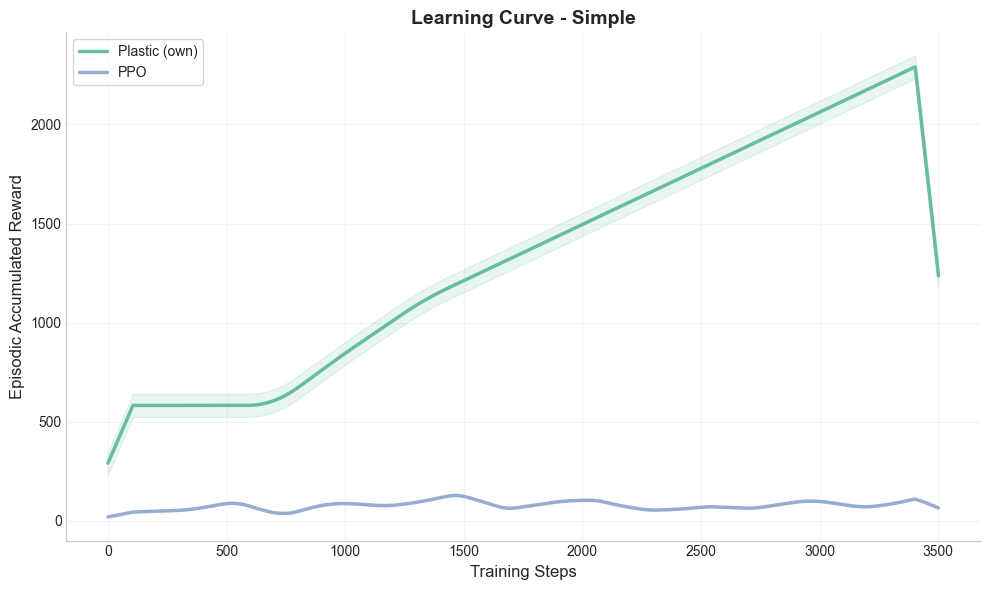

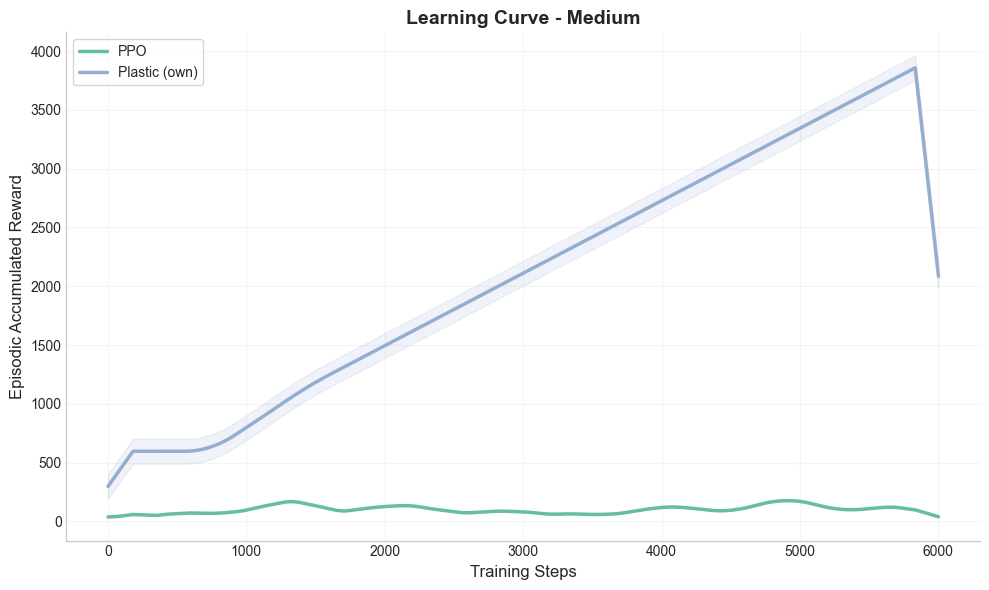

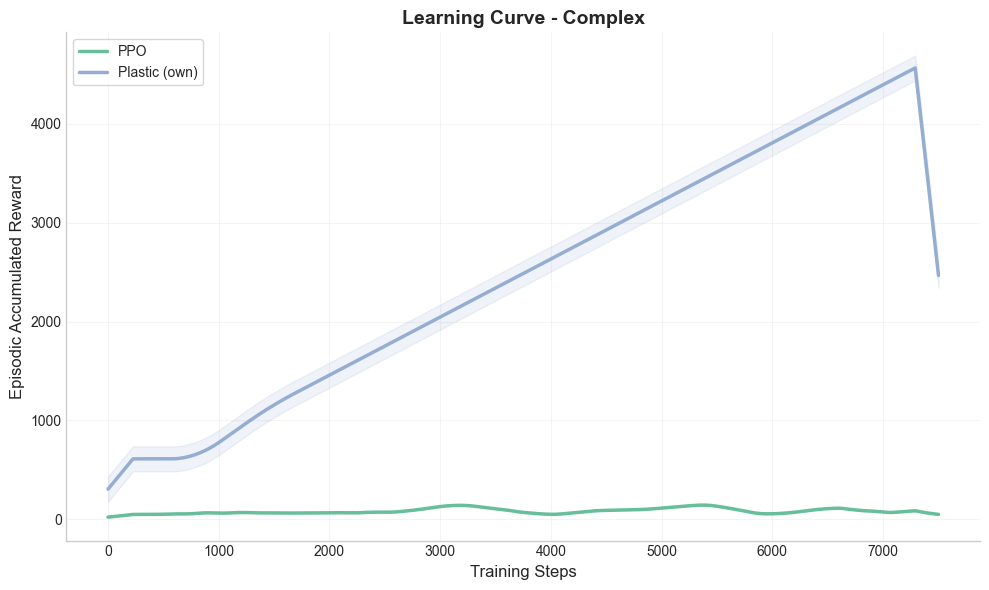

In [92]:
plot_scenario("scratch", "simple", datasets)
plot_scenario("scratch", "medium", datasets)
plot_scenario("scratch", "complex", datasets)

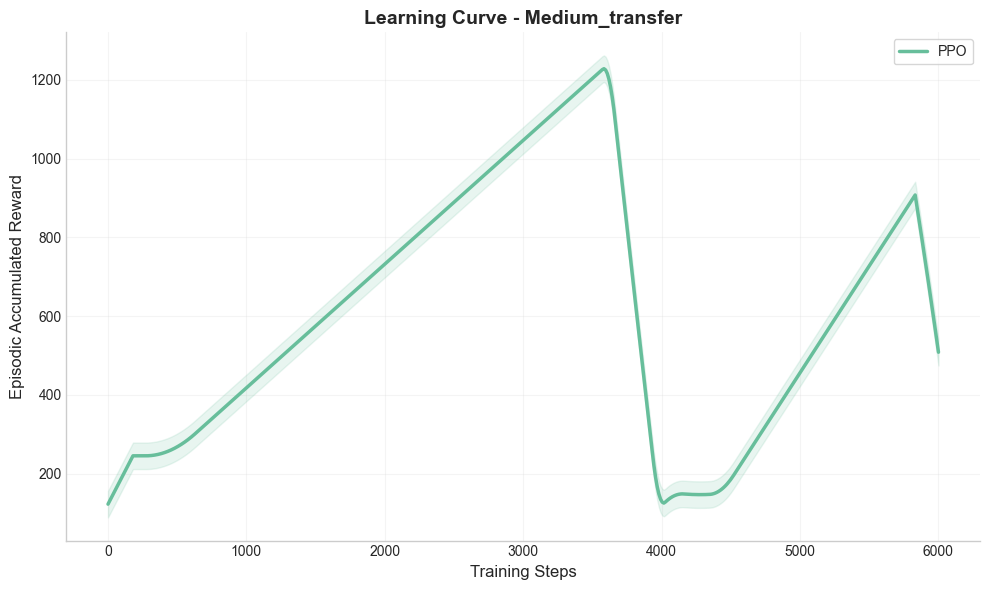

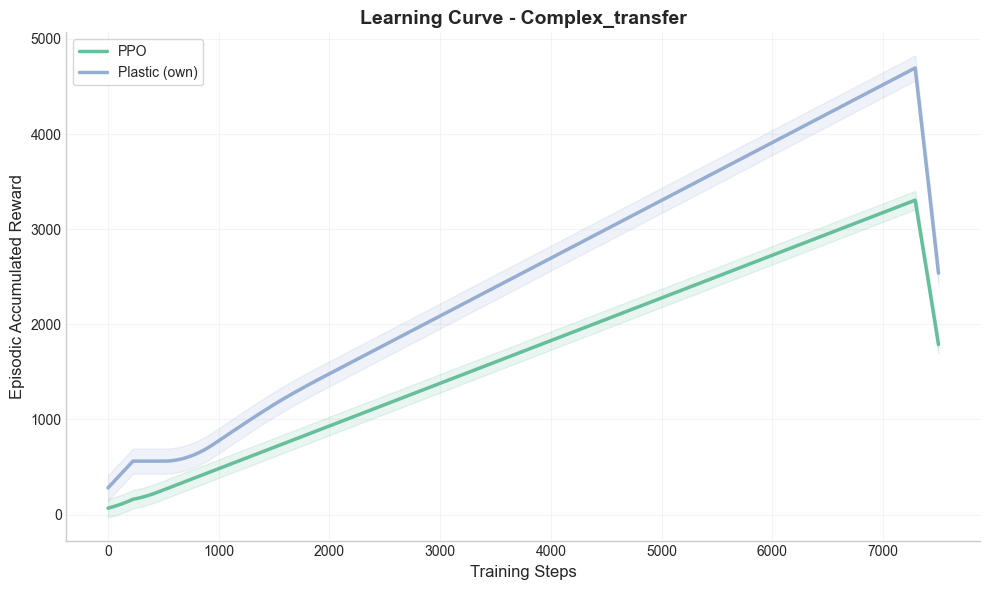

In [85]:
plot_scenario("transfer", "medium_transfer", datasets)
plot_scenario("transfer", "complex_transfer", datasets)

In [86]:
for i,(name,df) in enumerate(datasets.items()):
    print("df", name)
    print(df['reward'].describe())

AttributeError: 'list' object has no attribute 'items'

## 🎯 Steps to Threshold

## 📊 AUC

In [ ]:
def plot_auc_all(datasets):

    colors = {
        "Plastic (own)": "#67be9b",
        "PPO": "#FFAC1C",
        "PPO-curriculum": "#f1db42"
    }

    auc_results = {}

    escenarios = sorted(set(d["escenario"] for d in datasets))
    tipos = sorted(set(d["type"] for d in datasets))

    # ---------------------------
    # 1. calcular AUC por grupo
    # ---------------------------
    for escenario in escenarios:
        for tipo in tipos:

            group_key = f"{escenario.capitalize()}-{tipo}"

            # filtrar datasets
            group_datasets = [
                d for d in datasets
                if d["escenario"] == escenario and d["type"] == tipo
            ]

            if len(group_datasets) == 0:
                continue

            # rango común
            max_common_steps = min(d["data"]["steps"].max() for d in group_datasets)
            common_steps = np.linspace(0, max_common_steps, 500)

            auc_results[group_key] = {}

            for dataset in group_datasets:

                df = dataset["data"].sort_values("steps").copy()

                df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
                df["episode_reward"] = pd.to_numeric(df["episode_reward"], errors="coerce")

                df = df.dropna()
                df = df.drop_duplicates("steps")

                x = df["steps"].values.astype(float)
                y = df["episode_reward"].values.astype(float)

                if len(x) < 2:
                    continue

                interp_rewards = np.interp(common_steps, x, y)

                window = 30
                smooth = np.convolve(interp_rewards, np.ones(window)/window, mode='same')

                auc = trapezoid(smooth, common_steps)
                auc_norm = auc / max_common_steps

                auc_results[group_key][dataset["name_in_graph"]] = auc_norm

    # ---------------------------
    # 2. construir gráfica
    # ---------------------------
    fig, ax = plt.subplots(figsize=(12,6))

    group_names = list(auc_results.keys())
    methods = list(colors.keys())

    x = np.arange(len(group_names))
    width = 0.25

    for i, method in enumerate(methods):

        values = []

        for group in group_names:
            values.append(auc_results[group].get(method, 0))

        ax.bar(
            x + i * width,
            values,
            width,
            label=method,
            color=colors[method]
        )

    # etiquetas
    ax.set_xticks(x + width)
    ax.set_xticklabels(group_names, rotation=30)

    ax.set_ylabel("AUC")
    ax.set_title("AUC Comparison Across Scenarios and Training Types", weight='bold')

    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # quitar bordes
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig.savefig("auc_all_scenarios.pdf", bbox_inches='tight')

    plt.show()

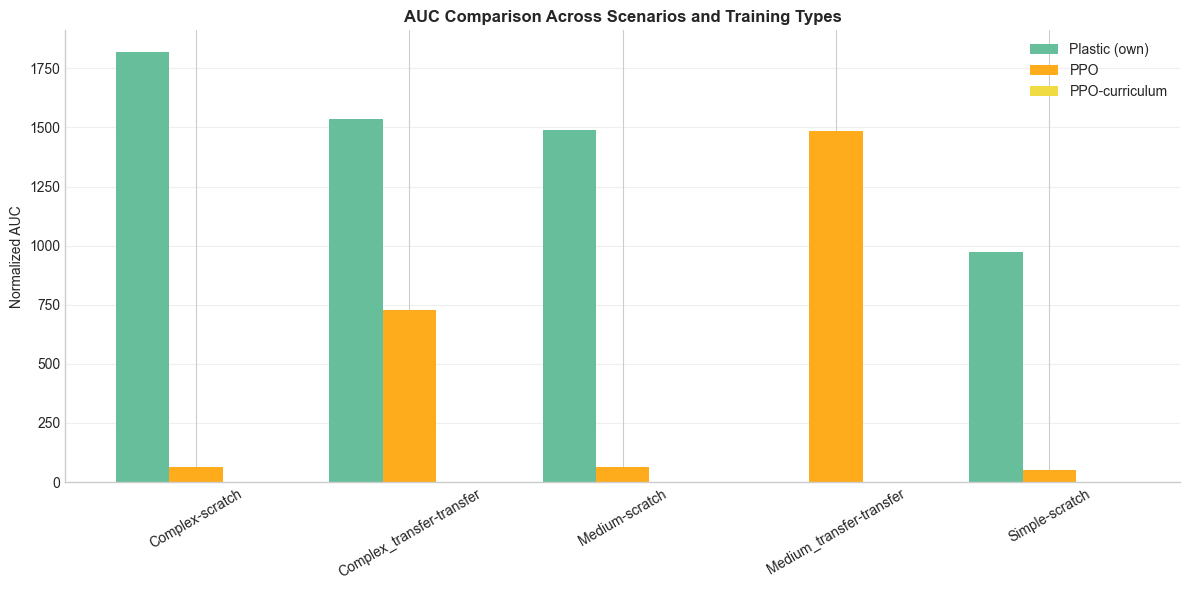

In [ ]:
plot_auc_all(datasets)

## 📉 Stability

In [ ]:
def plot_stability_all(datasets):

    colors = {
        "Plastic (own)": "#67be9b",
        "PPO": "#FFAC1C",
        "PPO-curriculum": "#f1db42"
    }

    stability_results = {}

    escenarios = sorted(set(d["escenario"] for d in datasets))
    tipos = sorted(set(d["type"] for d in datasets))

    # ---------------------------
    # 1. calcular estabilidad
    # ---------------------------
    for escenario in escenarios:
        for tipo in tipos:

            group_key = f"{escenario.capitalize()}-{tipo}"

            group_datasets = [
                d for d in datasets
                if d["escenario"] == escenario and d["type"] == tipo
            ]

            if len(group_datasets) == 0:
                continue

            stability_results[group_key] = {}

            for dataset in group_datasets:

                df = dataset["data"].copy()

                df["episode_reward"] = pd.to_numeric(df["episode_reward"], errors="coerce")
                df = df.dropna()

                if len(df) < 10:
                    continue

                # suavizado
                smooth = df["episode_reward"].rolling(20, min_periods=1).mean()

                # desviación móvil
                rolling_std = smooth.rolling(50, min_periods=1).std()

                # estabilidad global (menor = mejor)
                stability_value = rolling_std.mean()

                stability_results[group_key][dataset["name_in_graph"]] = stability_value

    # ---------------------------
    # 2. gráfica
    # ---------------------------
    fig, ax = plt.subplots(figsize=(12,6))

    group_names = list(stability_results.keys())
    methods = list(colors.keys())

    x = np.arange(len(group_names))
    width = 0.25

    for i, method in enumerate(methods):

        values = []

        for group in group_names:
            values.append(stability_results[group].get(method, np.nan))

        ax.bar(
            x + i * width,
            values,
            width,
            label=method,
            color=colors[method]
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(group_names, rotation=30)

    ax.set_ylabel("Reward Std (lower is better)")
    ax.set_title("Stability Across Scenarios and Training Types", weight='bold')

    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # quitar bordes
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig.savefig("stability_all_scenarios.pdf", bbox_inches='tight')

    plt.show()

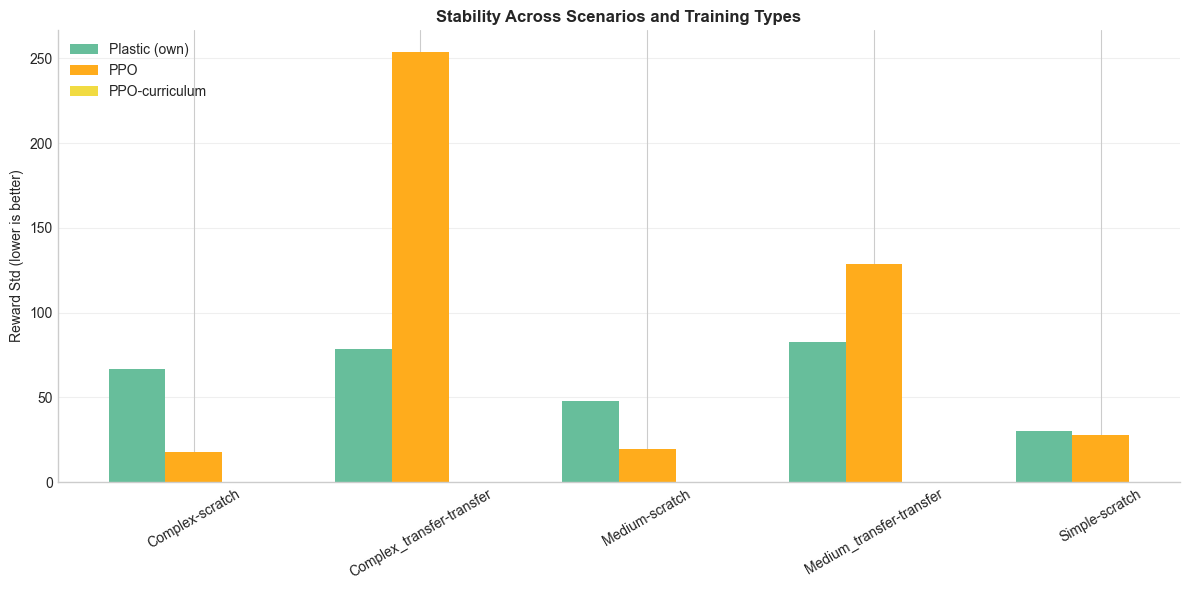

In [ ]:
plot_stability_all(datasets)

### Plastic analisys

In [ ]:
df_plastic = datasets.get("Plastic (own)")

### metricas generales

In [ ]:
auc_results = {}

for dataset in datasets:

    name = dataset["name_in_graph"]
    df = dataset["data"].copy()

    # -------------------------
    # 1. limpiar
    # -------------------------
    df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
    df["episode_reward"] = pd.to_numeric(df["episode_reward"], errors="coerce")

    df = df.dropna()
    df = df.drop_duplicates("steps")
    df = df.sort_values("steps")

    steps = df["steps"].values.astype(float)
    rewards = df["episode_reward"].values.astype(float)

    if len(steps) < 2:
        auc_results[name] = np.nan
        continue

    # -------------------------
    # 2. suavizado
    # -------------------------
    window = 20
    rewards_smooth = np.convolve(
        rewards,
        np.ones(window) / window,
        mode="same"
    )

    # -------------------------
    # 3. AUC
    # -------------------------
    auc = trapezoid(rewards_smooth, steps)

    # -------------------------
    # 4. normalización
    # -------------------------
    total_steps = steps[-1]

    auc_normalized = auc / total_steps if total_steps > 0 else np.nan

    auc_results[name] = auc_normalized

In [ ]:
auc_results

{'PPO': np.float64(270.3428025942061),
 'Plastic (own)': np.float64(605.0191215796183)}

In [ ]:
for data in datasets:
    rewards = data.get("data")["episode_reward"].values

    print(f"Episodic reward mean {data.get("name_in_graph")}", rewards.mean())

Episodic reward mean PPO 376.5810483096662
Episodic reward mean PPO 763.7541537267795
Episodic reward mean Plastic (own) 712.1916361169763
Episodic reward mean PPO 193.21916935985493
Episodic reward mean Plastic (own) 827.686201682725
Episodic reward mean PPO 200.65950103815487
Episodic reward mean Plastic (own) 2608.430914294643
Episodic reward mean PPO 184.8153460233494
Episodic reward mean Plastic (own) 948.9293669440958
Episodic reward mean Plastic (own) 835.3842327781839
